In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

### Pseudo RNN

In [2]:
timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))

In [3]:
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []

for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t

final_output_sequence = np.concatenate(successive_outputs, axis=0)
final_output_sequence.reshape(timesteps, output_features)

array([[0.99999983, 1.        , 0.99999981, ..., 0.99999996, 1.        ,
        0.99999975],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(100, 64))

### RNN in Keras

In [4]:
# An RNN layer that can process sequences of any length
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = keras.layers.SimpleRNN(16)(inputs)
outputs.shape

(None, 16)

In [5]:
# An RNN layer that returns only its last output step
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = keras.layers.SimpleRNN(16, return_sequences=False)(inputs)
outputs.shape

(None, 16)

In [6]:
# An RNN layer that returns its full output sequence
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = keras.layers.SimpleRNN(16, return_sequences=True)(inputs)
outputs.shape

(None, 120, 16)

In [7]:
# Stacked RNN Layers
inputs = keras.Input(shape=(steps, num_features))
x = keras.layers.SimpleRNN(16, return_sequences=True)(inputs)
x = keras.layers.SimpleRNN(16, return_sequences=True)(x)
outputs = keras.layers.SimpleRNN(16)(x)
outputs.shape

(None, 16)

### Load Dataset

In [8]:
# Load csv dataset
df = pd.read_csv("datasets/jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [9]:
temperature = df["T (degC)"]

# All but date
raw_data = df[['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)']]

In [10]:
num_train_samples = int(0.5 * len(raw_data)) # 50%
num_val_samples = int(0.25 * len(raw_data)) # 25%
num_test_samples = len(raw_data) - num_train_samples - num_val_samples # 25%

mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std


In [11]:
# Train - Test - Val Split Config
sampling_rate = 6  # Observations will be sampled at one data point per hour: we will only keep one data point out of six.
sequence_length = 120  # Observations will go back five days (120 hours)
delay = sampling_rate * (sequence_length + 24 - 1) #  The target for a sequence will be the temperature 24 hours after the end of the sequence.
batch_size = 256


# Train - Test - Val Split
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

### Recurrent dropout

In [12]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras", save_best_only=True)]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 85s 100ms/step - loss: 32.0878 - mae: 4.1978 - val_loss: 11.4909 - val_mae: 2.5965
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 75s 91ms/step - loss: 16.2452 - mae: 3.1294 - val_loss: 9.7057 - val_mae: 2.4135
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 85s 103ms/step - loss: 15.1821 - mae: 3.0268 - val_loss: 9.4094 - val_mae: 2.3827
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - loss: 14.6312 - mae: 2.9681 - val_loss: 9.1651 - val_mae: 2.3528
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - loss: 14.0559 - mae: 2.9092 - val_loss: 9.0044 - val_mae: 2.3311


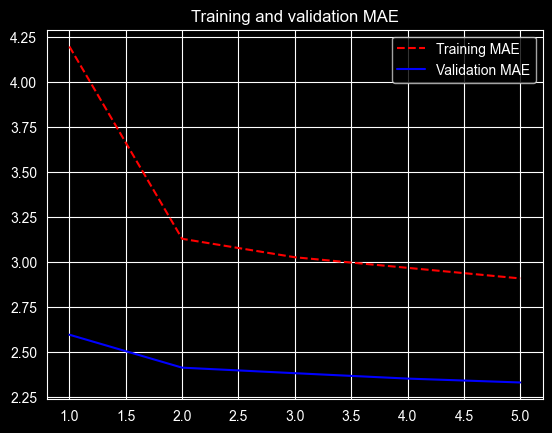

In [14]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Stacking recurrent layers

In [15]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = keras.layers.GRU(32, recurrent_dropout=0.5)(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 32)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras", save_best_only=True)]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 154s 180ms/step - loss: 32.3414 - mae: 4.1727 - val_loss: 11.1997 - val_mae: 2.5228
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 132s 161ms/step - loss: 15.2027 - mae: 3.0066 - val_loss: 9.1883 - val_mae: 2.3319
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 134s 163ms/step - loss: 13.9858 - mae: 2.8924 - val_loss: 8.7549 - val_mae: 2.2943
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 127s 156ms/step - loss: 13.5031 - mae: 2.8427 - val_loss: 8.8639 - val_mae: 2.3119
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 138s 168ms/step - loss: 13.0076 - mae: 2.7907 - val_loss: 8.5186 - val_mae: 2.2663


In [17]:
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 9.8198 - mae: 2.4370
Test MAE: 2.44


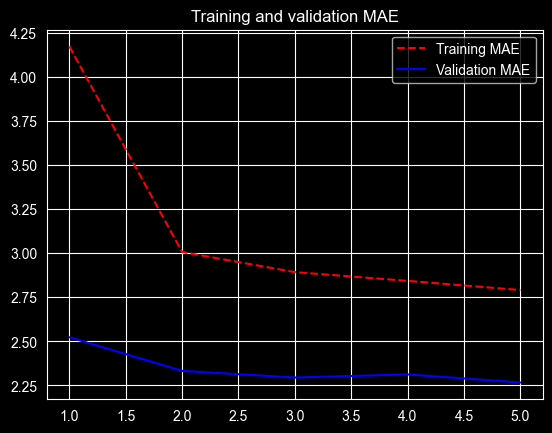

In [18]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Bidirectional recurrent layers

In [19]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.Bidirectional(keras.layers.LSTM(16))(inputs)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,001 (15.63 KB)

 Trainable params: 4,001 (15.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 60s 69ms/step - loss: 33.2194 - mae: 4.1770 - val_loss: 14.4760 - val_mae: 2.9276
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 12.8558 - mae: 2.8088 - val_loss: 11.3362 - val_mae: 2.6129
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 10.9396 - mae: 2.5812 - val_loss: 10.5438 - val_mae: 2.5363
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 9.7807 - mae: 2.4418 - val_loss: 10.1470 - val_mae: 2.4945
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 9.4536 - mae: 2.3981 - val_loss: 9.8625 - val_mae: 2.4615
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 9.0803 - mae: 2.3519 - val_loss: 9.6892 - val_mae: 2.4389
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - loss: 8.6831 - mae: 2.3009 - val_loss: 9.6039 - val_mae: 2.4263
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 8.3606 - mae: 2.2577 - val_loss: 9.5379 - val_mae: 2.4228
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

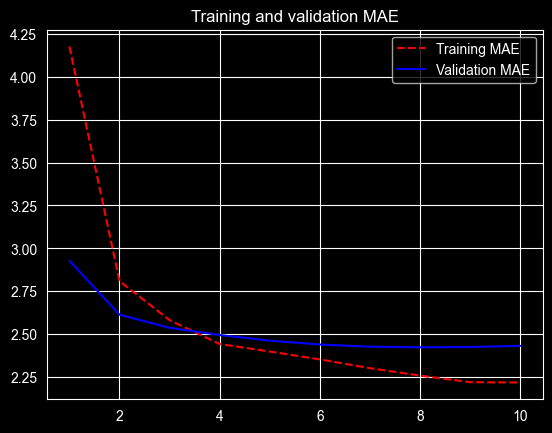

In [21]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()